In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

In [3]:
import os

print(os.getcwd())

c:\Users\krupa\OneDrive\Desktop\mutualfundanalytics\notebooks


In [4]:
import os

print(os.listdir())

['clean_data.py', 'EDA_Analysis.ipynb', 'load_db.py', 'Performance_Analytics.ipynb']


In [5]:
import os

print(os.getcwd())

c:\Users\krupa\OneDrive\Desktop\mutualfundanalytics\notebooks


In [6]:
import os

print(os.listdir("../data/processed"))

['02_nav_history.csv', 'cleaned_01_fund_master.csv', 'investor_transactions_clean.csv', 'nav_history_clean.csv', 'processed_01_fund_master.csv', 'scheme_performance_clean.csv']


In [7]:
import pandas as pd

fund_master = pd.read_csv("../data/processed/processed_01_fund_master.csv")

daily_nav = pd.read_csv("../data/processed/nav_history_clean.csv")

In [8]:
print(fund_master.columns)
print()

print(daily_nav.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [9]:
import os

print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'processed']


In [10]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [11]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='object')


In [12]:
daily_nav["date"] = pd.to_datetime(daily_nav["date"])

daily_nav = daily_nav.sort_values(["amfi_code", "date"])

daily_nav["daily_return"] = (
    daily_nav.groupby("amfi_code")["nav"].pct_change()
)

In [13]:
daily_nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [14]:
# Ensure data is sorted
daily_nav = daily_nav.sort_values(["amfi_code", "date"])

# Latest date available
latest_date = daily_nav["date"].max()

print("Latest NAV Date:", latest_date)

Latest NAV Date: 2026-05-29 00:00:00


In [15]:
# Function to calculate CAGR

def calculate_cagr(group, years):
    end_date = group["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    data = group[group["date"] >= start_date]

    if len(data) < 2:
        return np.nan

    start_nav = data.iloc[0]["nav"]
    end_nav = data.iloc[-1]["nav"]

    if start_nav <= 0:
        return np.nan

    cagr = (end_nav / start_nav) ** (1 / years) - 1
    return cagr

In [16]:
cagr_table = pd.DataFrame()

cagr_table["amfi_code"] = daily_nav["amfi_code"].unique()

cagr_table["CAGR_1Y"] = cagr_table["amfi_code"].apply(
    lambda x: calculate_cagr(
        daily_nav[daily_nav["amfi_code"] == x], 1
    )
)

cagr_table["CAGR_3Y"] = cagr_table["amfi_code"].apply(
    lambda x: calculate_cagr(
        daily_nav[daily_nav["amfi_code"] == x], 3
    )
)

cagr_table["CAGR_5Y"] = cagr_table["amfi_code"].apply(
    lambda x: calculate_cagr(
        daily_nav[daily_nav["amfi_code"] == x], 5
    )
)

cagr_table.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [17]:
cagr_table = cagr_table.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

cagr_table.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name
0,100016,-0.022243,0.012926,0.023168,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.037050,0.039164,0.039127,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.239860,-0.041524,0.069533,ABSL Small Cap Fund - Regular - Growth


In [18]:
cagr_table.to_csv(
    "../data/processed/cagr_comparison.csv",
    index=False
)

In [19]:
# Annual risk-free rate (6.5%)
risk_free_rate = 0.065

# Convert to daily rate
daily_rf = risk_free_rate / 252

print("Daily Risk-Free Rate:", daily_rf)

Daily Risk-Free Rate: 0.00025793650793650796


In [20]:
sharpe_table = daily_nav.groupby("amfi_code").agg(
    mean_return=("daily_return", "mean"),
    std_return=("daily_return", "std")
).reset_index()

sharpe_table["Sharpe_Ratio"] = (
    (sharpe_table["mean_return"] - daily_rf)
    / sharpe_table["std_return"]
) * np.sqrt(252)

sharpe_table.head()

,amfi_code,mean_return,std_return,Sharpe_Ratio
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [21]:
sharpe_table = sharpe_table.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sharpe_table.head()

,amfi_code,mean_return,std_return,Sharpe_Ratio,scheme_name
0,100016,0.000142,0.009164,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.000170,0.002460,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.000852,0.009177,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.000424,0.016251,0.162661,ABSL Small Cap Fund - Regular - Growth


In [22]:
sharpe_table = sharpe_table.sort_values(
    by="Sharpe_Ratio",
    ascending=False
)

sharpe_table.head(10)

,amfi_code,mean_return,std_return,Sharpe_Ratio,scheme_name
34,148567,0.001074,0.008941,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.001082,0.010008,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,0.001124,0.011134,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.000917,0.008656,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.001161,0.012152,1.180101,ICICI Pru Midcap Fund - Regular - Growth
38,149323,0.001055,0.011179,1.132122,DSP Midcap Fund - Regular - Growth
2,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,0.000865,0.008913,1.081659,Nippon India Large Cap Fund - Regular - Growth
3,101206,0.000852,0.009177,1.027213,ABSL Frontline Equity Fund - Regular - Growth
24,120504,0.000843,0.009048,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


In [23]:
sharpe_table.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

In [24]:
sortino_table = daily_nav.groupby("amfi_code").apply(
    lambda x: pd.Series({
        "mean_return": x["daily_return"].mean(),
        "downside_std": x.loc[x["daily_return"] < 0, "daily_return"].std()
    })
).reset_index()

sortino_table.head()

C:\Users\krupa\AppData\Local\Temp\ipykernel_17812\3089047672.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sortino_table = daily_nav.groupby("amfi_code").apply(


,amfi_code,mean_return,downside_std
0,100016,0.000142,0.005261
1,100025,0.000170,0.001481
2,100033,0.001080,0.007133
3,101206,0.000852,0.005238
4,101207,0.000424,0.009555


In [25]:
sortino_table["Sortino_Ratio"] = (
    (sortino_table["mean_return"] - daily_rf)
    / sortino_table["downside_std"]
) * np.sqrt(252)

sortino_table.head()

,amfi_code,mean_return,downside_std,Sortino_Ratio
0,100016,0.000142,0.005261,-0.351047
1,100025,0.000170,0.001481,-0.941821
2,100033,0.001080,0.007133,1.829134
3,101206,0.000852,0.005238,1.799563
4,101207,0.000424,0.009555,0.276644


In [26]:
sortino_table = sortino_table.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sortino_table.head()

,amfi_code,mean_return,downside_std,Sortino_Ratio,scheme_name
0,100016,0.000142,0.005261,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.000170,0.001481,-0.941821,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.001080,0.007133,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.000852,0.005238,1.799563,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.000424,0.009555,0.276644,ABSL Small Cap Fund - Regular - Growth


In [27]:
sortino_table = sortino_table.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

sortino_table.head(10)

,amfi_code,mean_return,downside_std,Sortino_Ratio,scheme_name
34,148567,0.001074,0.005428,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.001082,0.005531,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,0.001124,0.006404,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.000917,0.004887,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.001161,0.007067,2.029353,ICICI Pru Midcap Fund - Regular - Growth
38,149323,0.001055,0.006750,1.875101,DSP Midcap Fund - Regular - Growth
9,118632,0.000865,0.005211,1.850133,Nippon India Large Cap Fund - Regular - Growth
2,100033,0.001080,0.007133,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,0.000843,0.005145,1.805294,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,0.000852,0.005238,1.799563,ABSL Frontline Equity Fund - Regular - Growth


In [28]:
sortino_table.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

In [29]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [30]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='object')


In [31]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [32]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values(["index_name", "date"])

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"].pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [33]:
nifty100 = benchmark[
    benchmark["index_name"].str.contains("100", case=False, na=False)
].copy()

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [34]:
alpha_beta_list = []

for fund in daily_nav["amfi_code"].unique():

    fund_data = daily_nav[daily_nav["amfi_code"] == fund][["date", "daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha_beta_list.append({
            "amfi_code": fund,
            "Alpha": intercept * 252,
            "Beta": slope
        })

In [35]:
alpha_beta = pd.DataFrame(alpha_beta_list)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [36]:
alpha_beta = alpha_beta.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta.head()

,amfi_code,Alpha,Beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [37]:
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [38]:
drawdown_list = []

for fund in daily_nav["amfi_code"].unique():

    df = daily_nav[daily_nav["amfi_code"] == fund].copy()
    df = df.sort_values("date")

    df["running_max"] = df["nav"].cummax()
    df["drawdown"] = (df["nav"] / df["running_max"]) - 1

    max_dd = df["drawdown"].min()

    worst_row = df.loc[df["drawdown"].idxmin()]

    drawdown_list.append({
        "amfi_code": fund,
        "Maximum_Drawdown": max_dd,
        "Worst_Date": worst_row["date"]
    })

In [39]:
drawdown_table = pd.DataFrame(drawdown_list)

drawdown_table.head()

,amfi_code,Maximum_Drawdown,Worst_Date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [40]:
drawdown_table = drawdown_table.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

drawdown_table.head()

,amfi_code,Maximum_Drawdown,Worst_Date,scheme_name
0,100016,-0.247344,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth


In [41]:
drawdown_table.to_csv(
    "../data/processed/maximum_drawdown.csv",
    index=False
)

In [42]:
print(cagr_table.columns)
print(sharpe_table.columns)
print(alpha_beta.columns)
print(drawdown_table.columns)


Index(['amfi_code', 'CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y', 'scheme_name'], dtype='object')
Index(['amfi_code', 'mean_return', 'std_return', 'Sharpe_Ratio',
       'scheme_name'],
      dtype='object')
Index(['amfi_code', 'Alpha', 'Beta', 'scheme_name'], dtype='object')
Index(['amfi_code', 'Maximum_Drawdown', 'Worst_Date', 'scheme_name'], dtype='object')


In [43]:
scorecard = cagr_table.merge(
    sharpe_table[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code", "Alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_table[["amfi_code", "Maximum_Drawdown"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    fund_master[["amfi_code", "expense_ratio_pct"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name,Sharpe_Ratio,Alpha,Maximum_Drawdown,expense_ratio_pct
0,100016,-0.022243,0.012926,0.023168,HDFC Top 100 Fund - Regular Plan - Growth,-0.201517,0.037476,-0.247344,1.55
1,100025,0.037050,0.039164,0.039127,HDFC Short Term Debt Fund - Regular - Growth,-0.567095,0.042818,-0.043083,0.56
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,0.271954,-0.162172,1.38
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth,1.027213,0.213998,-0.112916,1.60
4,101207,-0.239860,-0.041524,0.069533,ABSL Small Cap Fund - Regular - Growth,0.162661,0.108971,-0.354469,1.53


In [44]:
scorecard["Return_Rank"] = scorecard["CAGR_3Y"].rank(ascending=False)

scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["Drawdown_Rank"] = scorecard["Maximum_Drawdown"].rank(ascending=False)

In [45]:
scorecard["Fund_Score"] = (
    0.30 * scorecard["Return_Rank"] +
    0.25 * scorecard["Sharpe_Rank"] +
    0.20 * scorecard["Alpha_Rank"] +
    0.15 * scorecard["Expense_Rank"] +
    0.10 * scorecard["Drawdown_Rank"]
)

In [46]:
max_score = scorecard["Fund_Score"].max()
min_score = scorecard["Fund_Score"].min()

scorecard["Fund_Score"] = (
    (max_score - scorecard["Fund_Score"])
    / (max_score - min_score)
) * 100

scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name,Sharpe_Ratio,Alpha,Maximum_Drawdown,expense_ratio_pct,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score
34,148567,0.203607,0.340009,0.267993,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,0.269838,-0.112657,1.46,2.0,1.0,7.0,23.0,8.0,100.000000
25,120505,0.296047,0.317775,0.283768,ICICI Pru Midcap Fund - Regular - Growth,1.180101,0.292636,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0,94.439618
30,120843,0.266571,0.295828,0.267425,Kotak Flexicap Fund - Regular - Growth,1.306744,0.273305,-0.129740,1.45,7.0,2.0,5.0,22.0,13.0,94.092094
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,0.271954,-0.162172,1.38,4.0,7.0,6.0,17.0,20.0,92.354474
24,120504,0.130643,0.324874,0.202340,ICICI Pru Bluechip Fund - Direct - Growth,1.026524,0.211948,-0.125883,0.80,3.0,10.0,13.0,12.0,12.0,91.311903
16,119094,0.222611,0.351118,0.244453,Axis Midcap Fund - Regular - Growth,0.998231,0.260767,-0.209609,1.38,1.0,11.0,9.0,17.0,28.0,87.141616
19,119551,0.604373,0.304565,0.223849,SBI Bluechip Fund - Regular Plan - Growth,1.208267,0.232010,-0.150124,1.54,6.0,4.0,10.0,30.5,17.0,84.100782
36,148569,0.397518,0.291789,0.276299,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,0.282704,-0.163967,1.60,8.0,3.0,4.0,36.5,21.0,82.536924
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth,1.027213,0.213998,-0.112916,1.60,9.0,9.0,12.0,36.5,9.0,74.891399
21,119598,0.827761,0.266699,0.280332,SBI Small Cap Fund - Regular Plan - Growth,0.945308,0.303370,-0.287060,1.43,12.0,14.0,1.0,21.0,36.0,73.761946


In [47]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [48]:
print(benchmark["index_name"].unique())

['BSE_SMALLCAP' 'CRISIL_GILT' 'CRISIL_LIQUID' 'NIFTY100' 'NIFTY50'
 'NIFTY500' 'NIFTY_MIDCAP150']


In [49]:
top5 = scorecard.nlargest(5, "Fund_Score")["amfi_code"].tolist()

top5

[148567, 120505, 120843, 100033, 120504]

In [50]:
fund_plot = daily_nav[daily_nav["amfi_code"].isin(top5)].copy()

fund_plot = fund_plot.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [51]:
benchmark_plot = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

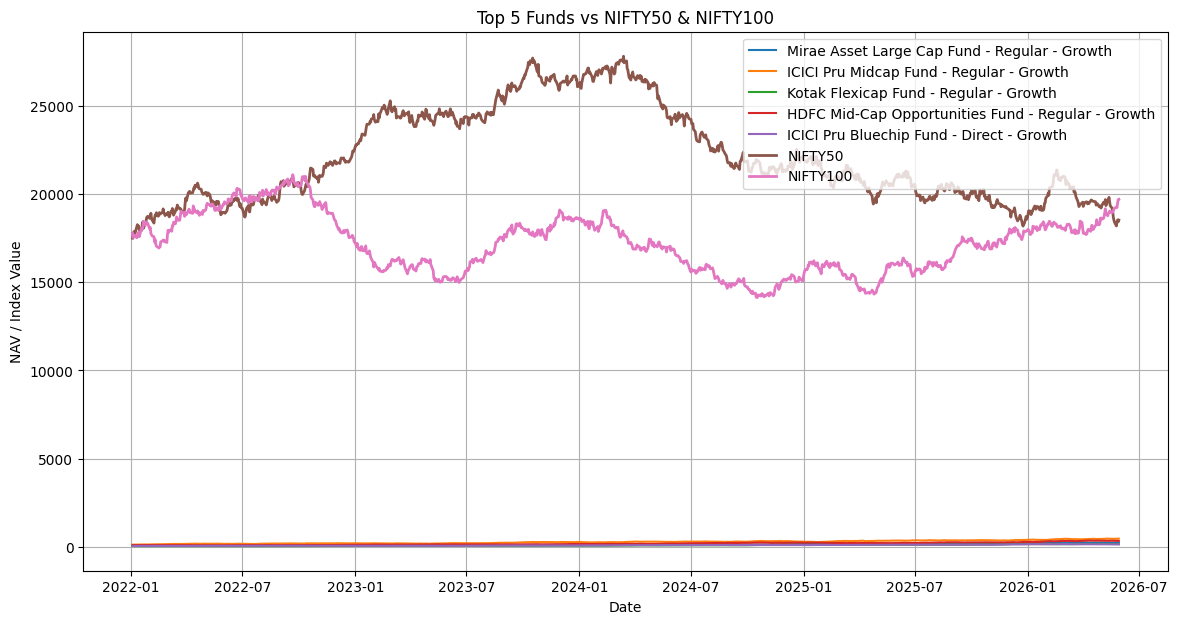

In [52]:
plt.figure(figsize=(14,7))

# Plot Top 5 Funds
for fund in top5:
    temp = fund_plot[fund_plot["amfi_code"] == fund]
    plt.plot(
        temp["date"],
        temp["nav"],
        label=temp["scheme_name"].iloc[0]
    )

# Plot Benchmarks
for idx in ["NIFTY50", "NIFTY100"]:
    temp = benchmark_plot[
        benchmark_plot["index_name"] == idx
    ]
    plt.plot(
        temp["date"],
        temp["close_value"],
        linewidth=2,
        label=idx
    )

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")
plt.xlabel("Date")
plt.ylabel("NAV / Index Value")
plt.legend()
plt.grid(True)

plt.show()

In [53]:
plt.figure(figsize=(14,7))

for fund in top5:
    temp = fund_plot[fund_plot["amfi_code"] == fund]
    plt.plot(temp["date"], temp["nav"])

for idx in ["NIFTY50", "NIFTY100"]:
    temp = benchmark_plot[
        benchmark_plot["index_name"] == idx
    ]
    plt.plot(temp["date"], temp["close_value"])

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")
plt.grid(True)

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

In [54]:
# NIFTY100 benchmark returns
nifty100_returns = benchmark[
    benchmark["index_name"] == "NIFTY100"
][["date", "benchmark_return"]]

tracking_error = []

for fund in top5:
    fund_returns = daily_nav[
        daily_nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_returns,
        nifty100_returns,
        on="date"
    ).dropna()

    te = (
        (merged["daily_return"] - merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_error.append({
        "amfi_code": fund,
        "Tracking_Error": te
    })

tracking_error = pd.DataFrame(tracking_error)

tracking_error = tracking_error.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

tracking_error

,amfi_code,Tracking_Error,scheme_name
0,148567,0.189664,Mirae Asset Large Cap Fund - Regular - Growth
1,120505,0.231968,ICICI Pru Midcap Fund - Regular - Growth
2,120843,0.206425,Kotak Flexicap Fund - Regular - Growth
3,100033,0.228699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,120504,0.191587,ICICI Pru Bluechip Fund - Direct - Growth


In [55]:
tracking_error.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)